In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("cleaned_transactions.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


# **Basic EDA**

In [3]:
df.shape

(514547, 9)

In [4]:
null_values = df.isna().sum().sort_values(ascending=False)
print(null_values[null_values > 0])

Customer ID    103815
dtype: int64


In [5]:
# display the count of unique values in each col

print("Number of unique values for each column:")

unique_counts = {}
for col in df.columns:
    unique_counts[col] = df[col].nunique()

unique_df = pd.DataFrame(unique_counts.items(), columns=['Column', 'Unique Count'])
display(unique_df)

Number of unique values for each column:


,Column,Unique Count
0,InvoiceNo,25324
1,StockCode,4265
2,Description,4549
3,Quantity,563
4,InvoiceDate,23213
5,Price,1500
6,Customer ID,4381
7,Country,40
8,transaction_type,2


There are **4,381 customers from 40 Countries**. As expected, there are two transaction types that I created in data cleaning step.

## Defining Churn

In [6]:
# before assigning churn class, filter for only registered customers
df = df[df['Customer ID'].notna()]
df.shape

(410732, 9)

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

earliest_date = df['InvoiceDate'].min()
latest_date = df['InvoiceDate'].max()

print(f"Earliest Invoice Date: {earliest_date}")
print(f"Latest Invoice Date: {latest_date}")

Earliest Invoice Date: 2009-12-01 07:45:00
Latest Invoice Date: 2010-12-09 20:01:00


The invoice dates indicate that the dataset covers a period of just over one year, from December 2009 to December 2010.

To perform customer churn analysis I first determined each customer's last activity date, defining **a churn inactivity threshold of 3 months**. I assigned churn status (active/churned), calculated the overall churn rate, and visualized the distribution of active vs. churned customers.

#### Determine Last Activity Date

In [8]:
# take only transactions with positive quantity (i.e. purchases, not returns)
df = df[df["Quantity"] > 0]

customer_last_activity = df.groupby('Customer ID')['InvoiceDate'].max()
print("Customer Last Activity Dates (first 5 customers):")
print(customer_last_activity.head())

Customer Last Activity Dates (first 5 customers):
Customer ID
12346.0   2010-06-28 13:53:00
12347.0   2010-12-07 14:57:00
12348.0   2010-09-27 14:59:00
12349.0   2010-10-28 08:23:00
12351.0   2010-11-29 15:23:00
Name: InvoiceDate, dtype: datetime64[ns]


#### Identify One-Time Buyers

Before assigning churn, I identified and separated one-time buyers from repeat customers their purchase frequency.I then labeled true churners as repeat customers who have gone inactive in the last 90 days.

I calculated the number of unique invoices (or transactions) for each customer to identify those who have made only a single purchase and classified them as **one-time buyers**.


In [9]:
# Analyze purchase frequency for one-time buyers vs repeat buyers
customer_purchase_counts = df.groupby('Customer ID')['InvoiceNo'].nunique()

one_time_buyers = customer_purchase_counts[customer_purchase_counts == 1]

print(f"Total number of one-time buyers: {len(one_time_buyers)}")
print("\nCustomer Purchase Counts (first 5 customers):")
print(customer_purchase_counts.head())

Total number of one-time buyers: 1419

Customer Purchase Counts (first 5 customers):
Customer ID
12346.0    11
12347.0     2
12348.0     1
12349.0     3
12351.0     1
Name: InvoiceNo, dtype: int64


#### Determine Last Activity Date

In [10]:
# filter for repeat customers and analyze their last activity dates
repeat_customer_ids = customer_purchase_counts[customer_purchase_counts > 1].index
repeat_customer_last_activity = customer_last_activity[repeat_customer_ids]

print(f"Total number of repeat customers: {len(repeat_customer_ids)}")
print("\nRepeat Customer Last Activity Dates (first 5 customers):")
print(repeat_customer_last_activity.head())

Total number of repeat customers: 2893

Repeat Customer Last Activity Dates (first 5 customers):
Customer ID
12346.0   2010-06-28 13:53:00
12347.0   2010-12-07 14:57:00
12349.0   2010-10-28 08:23:00
12352.0   2010-11-29 10:07:00
12356.0   2010-11-24 12:24:00
Name: InvoiceDate, dtype: datetime64[ns]


#### Churn Inactivity Threshold

I set a threshold for inactivity of 90 days (3 months) to define churn. This is the period after which a customer with no activity is considered churned. 

In [11]:
churn_threshold_months = 3 # Define churn threshold in months
churn_threshold_days = churn_threshold_months * 30 # convert into days 

observation_end_date = df['InvoiceDate'].max()

print(f"Churn Inactivity Threshold: {churn_threshold_months} months ({churn_threshold_days} days)")
print(f"Observation End Date (latest transaction in data): {observation_end_date}")

Churn Inactivity Threshold: 3 months (90 days)
Observation End Date (latest transaction in data): 2010-12-09 20:01:00


#### Recency for Repeat Customers

I calculated the recency for these repeat customers as the number of days since their last activity relative to the previously defined `observation_end_date`


In [12]:
# make sure the reference dates are datetime objects
observation_end_date = pd.to_datetime(observation_end_date)
repeat_customer_last_activity = pd.to_datetime(repeat_customer_last_activity)

# last activity recency for repeat customers
repeat_customer_recency = (observation_end_date - repeat_customer_last_activity).dt.days

print("Repeat Customer Recency (days since last activity, first 5 customers):")
print(repeat_customer_recency.head())

Repeat Customer Recency (days since last activity, first 5 customers):
Customer ID
12346.0    164
12347.0      2
12349.0     42
12352.0     10
12356.0     15
Name: InvoiceDate, dtype: int64


#### Assign Churn Status

I assigned churn status (**active or churned**) to each repeat customer based on their last activity date and the defined inactivity threshold. 

In [13]:
# assign churn status for repeat customers
repeat_customer_churn_status = repeat_customer_recency.apply(lambda x: 'Churned' if x > churn_threshold_days else 'Active')

print("Repeat Customer Churn Status (first 5 customers):")
print(repeat_customer_churn_status.head())

Repeat Customer Churn Status (first 5 customers):
Customer ID
12346.0    Churned
12347.0     Active
12349.0     Active
12352.0     Active
12356.0     Active
Name: InvoiceDate, dtype: object


## Churn Rate and Distribution

I calculated churn rate for repeat customers and visualized this distribution as my initial analysis.



Total repeat customers: 2893
Active repeat customers: 2259
Churned repeat customers: 634
Overall Churn Rate for Repeat Customers: 21.91%


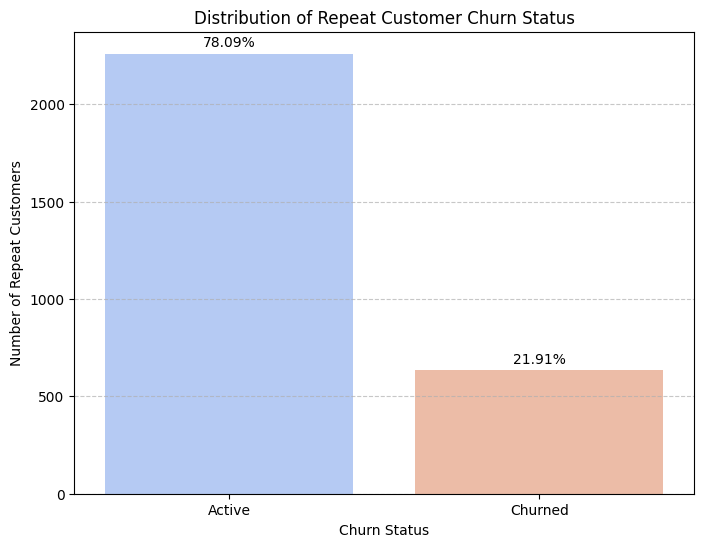

In [14]:
repeat_churn_counts = repeat_customer_churn_status.value_counts()
total_repeat_customers = repeat_customer_churn_status.count()
active_repeat_customers = repeat_churn_counts.get('Active', 0)
churned_repeat_customers = repeat_churn_counts.get('Churned', 0)

repeat_churn_rate = (churned_repeat_customers / total_repeat_customers) * 100

print(f"Total repeat customers: {total_repeat_customers}")
print(f"Active repeat customers: {active_repeat_customers}")
print(f"Churned repeat customers: {churned_repeat_customers}")
print(f"Overall Churn Rate for Repeat Customers: {repeat_churn_rate:.2f}%")

# Calculate percentages for the plot
repeat_churn_percentages = (repeat_churn_counts / total_repeat_customers) * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=repeat_churn_counts.index, y=repeat_churn_counts.values, palette='coolwarm')
plt.title('Distribution of Repeat Customer Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Number of Repeat Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of the bars
for index, value in enumerate(repeat_churn_counts.values):
    percentage = repeat_churn_percentages.iloc[index]
    plt.text(index, value + 20, # Adjust position of text
             f'{percentage:.2f}%', color='black', ha="center", va="bottom")

plt.show()

## Summary:

### Key Findings

*   A significant portion of the customer base consists of one-time buyers, totaling **1,488 customers**, representing those with only one unique invoice.
*   After excluding one-time buyers, **2,893 customers** were identified as **repeat customers**.
*   Based on a 3-month (90-day) inactivity threshold, **634** repeat customers were categorized as **Chruned**, while **2259** repeat customers were classified as **Active**
*   The **churn rate**, specifically for repeat customers, stands at **21.9%**.


### Insights and Next Steps

*   The distinction between one-time and repeat buyers is crucial for accurate churn analysis, as one-time purchases can artificially inflate overall customer counts without reflecting true long-term engagement.
*   Further investigation into the characteristics and behaviors of the **21.9% churned repeat customers** could reveal specific pain points or opportunities for targeted retention strategies, such as loyalty programs or win-back campaigns.
